# Customer Segmentation Analysis Using K-Means Clustering

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

%matplotlib inline

In [146]:
df=pd.read_csv("../data/online_retail_II.csv")

In [147]:
df.shape

(1067371, 8)

In [148]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [149]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [151]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [152]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [153]:
df.duplicated().sum()

np.int64(34335)

In [154]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [155]:
df[df['Quantity'] <= 0]
df[df['Price'] <= 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
1062442,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom
1063965,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,NaN,United Kingdom
1063966,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,NaN,United Kingdom
1064015,581408,85175,NaN,20,2011-12-08 14:06:00,0.0,NaN,United Kingdom


In [156]:
df_clean = df.copy()

In [157]:
df_clean = df_clean.dropna(subset=['Customer ID'])

In [158]:
df_clean=df_clean[df_clean['Quantity']>0]
df_clean=df_clean[df_clean['Price']>0]

In [159]:
df_clean.duplicated().sum()

np.int64(26124)

In [160]:
df_clean=df_clean.drop_duplicates()

In [161]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 779425 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  object        
 1   StockCode    779425 non-null  object        
 2   Description  779425 non-null  object        
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[ns]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  float64       
 7   Country      779425 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 53.5+ MB


In [162]:
df_clean.duplicated().sum()

np.int64(0)

In [163]:
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['Price']

In [164]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [165]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 779425 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  object        
 1   StockCode    779425 non-null  object        
 2   Description  779425 non-null  object        
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[ns]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  float64       
 7   Country      779425 non-null  object        
 8   TotalAmount  779425 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 59.5+ MB


In [166]:
df_clean['TotalAmount'].describe()

count    779425.000000
mean         22.291823
std         227.427075
min           0.001000
25%           4.950000
50%          12.480000
75%          19.800000
max      168469.600000
Name: TotalAmount, dtype: float64

In [167]:
df_clean[df_clean['TotalAmount'] <= 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount


In [168]:
Refrence_date=df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

In [169]:
RFM = df_clean.groupby('Customer ID').agg({'InvoiceDate' : lambda x: (Refrence_date - x.max()).days,
                                          'Invoice': 'nunique',
                                          'TotalAmount': 'sum'})

In [170]:
RFM.columns = ['Recency', 'Frequency', 'Monetary']

In [171]:
RFM.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [172]:
RFM.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,2955.904095
std,209.338707,13.009406,14440.852688
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,342.280000
50%,96.000000,3.000000,867.740000
75%,380.000000,7.000000,2248.305000
max,739.000000,398.000000,580987.040000


In [173]:
scaler = StandardScaler()

In [174]:
RFM_scaled = scaler.fit_transform(RFM)

In [175]:
RFM_scaled.shape

(5878, 3)

In [176]:
RFM_scaled[:5]

array([[ 0.59558355,  0.43899789,  5.16637792],
       [-0.95227909,  0.13150188,  0.13612722],
       [-0.60353226, -0.09912012, -0.06485654],
       [-0.87106408, -0.17599412,  0.10199614],
       [ 0.51914589, -0.40661612, -0.18154933]])

In [177]:
wcss = []

In [178]:
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(RFM_scaled)
    wcss.append(kmeans.inertia_)

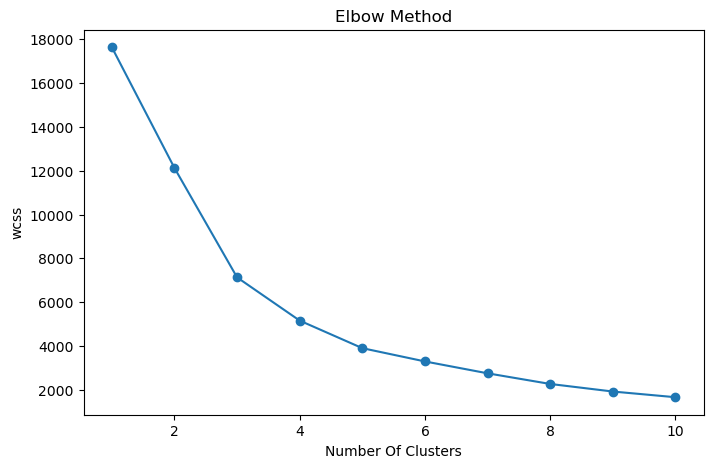

In [179]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss , marker='o')
plt.title('Elbow Method')
plt.xlabel('Number Of Clusters')
plt.ylabel('wcss')
plt.show()

In [180]:
kmeans = KMeans(n_clusters=3, random_state=42 , n_init=10)

In [181]:
RFM['Cluster'] = kmeans.fit_predict(RFM_scaled)

In [182]:
RFM.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,326,12,77556.46,0
12347.0,2,8,4921.53,0
12348.0,75,5,2019.40,0
12349.0,19,4,4428.69,0
12350.0,310,1,334.40,1


In [183]:
RFM['Cluster'].value_counts()

Cluster
0    3847
1    2009
2      22
Name: count, dtype: int64

In [184]:
RFM.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,66.296335,7.640239,3136.130157
1,461.861125,2.205077,747.333351
2,23.090909,143.045455,173123.584091


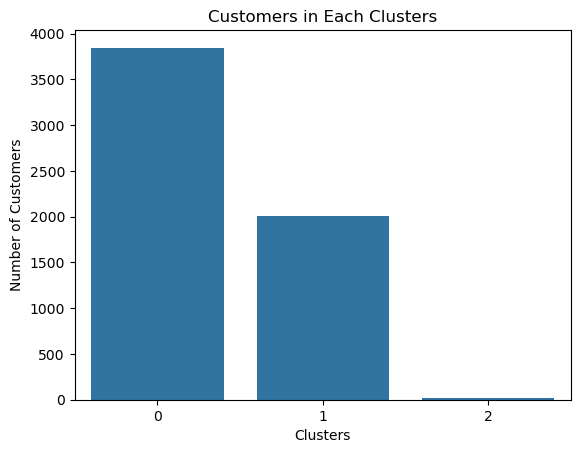

In [193]:
plt.Figure(figsize=(8,5))

sns.countplot(data=RFM , x="Cluster")

plt.title("Customers in Each Clusters")
plt.xlabel("Clusters")
plt.ylabel("Number of Customers")

plt.show()

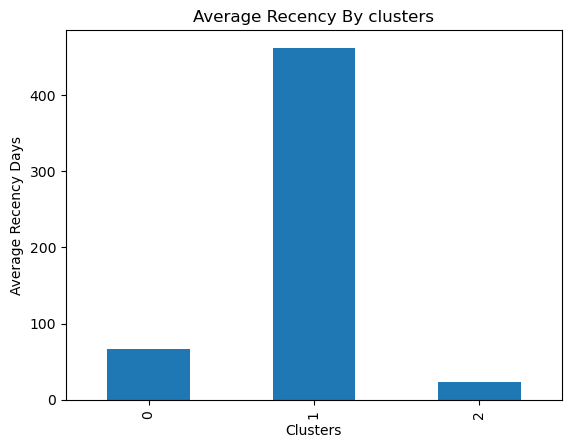

In [187]:
plt.Figure(figsize=(6,4))
RFM.groupby('Cluster')['Recency'].mean().plot(kind='bar')
plt.title('Average Recency By clusters')
plt.ylabel('Average Recency Days')
plt.xlabel('Clusters')

plt.show()

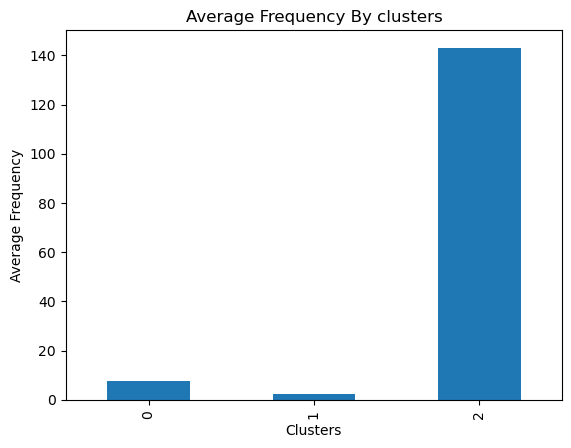

In [188]:
plt.Figure(figsize=(6,4))
RFM.groupby('Cluster')['Frequency'].mean().plot(kind='bar')
plt.title('Average Frequency By clusters')
plt.ylabel('Average Frequency')
plt.xlabel('Clusters')

plt.show()

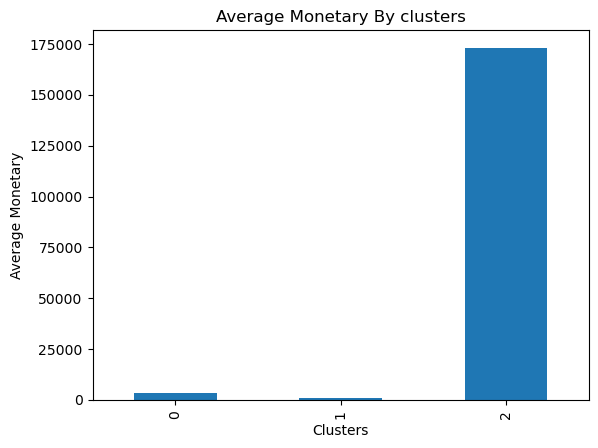

In [189]:
plt.Figure(figsize=(6,4))
RFM.groupby('Cluster')['Monetary'].mean().plot(kind='bar')
plt.title('Average Monetary By clusters')
plt.ylabel('Average Monetary')
plt.xlabel('Clusters')

plt.show()

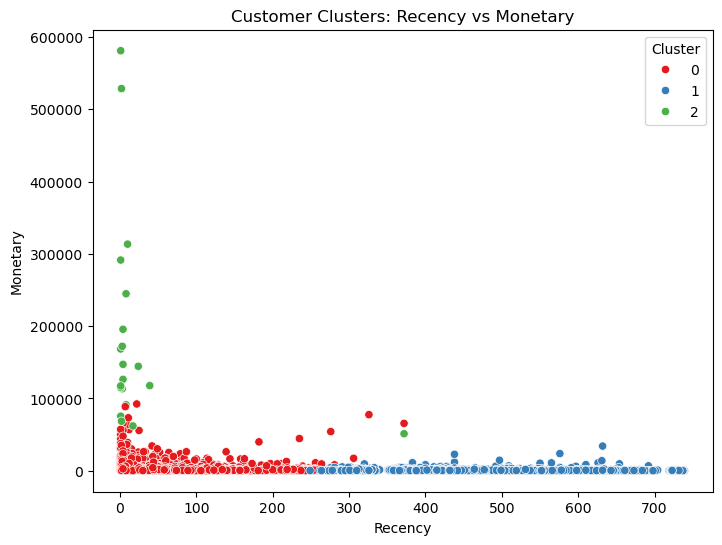

In [190]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=RFM,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set1'
)

plt.title('Customer Clusters: Recency vs Monetary')
plt.xlabel('Recency')
plt.ylabel('Monetary')

plt.show()

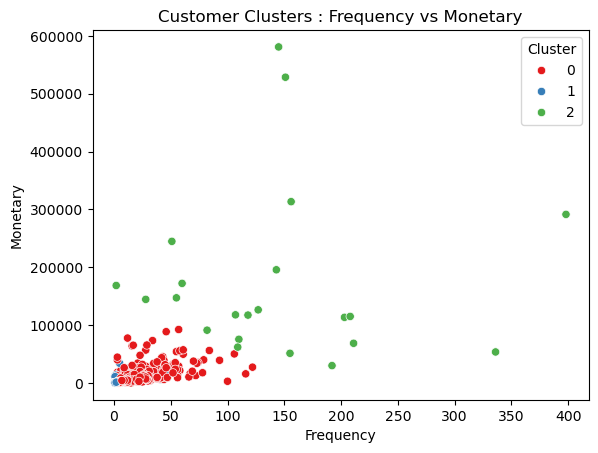

In [191]:
plt.Figure(figsize=(8,6))

sns.scatterplot(
    data=RFM,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set1'
)

plt.title('Customer Clusters : Frequency vs Monetary')
plt.xlabel('Frequency')
plt.ylabel('Monetary')

plt.show()

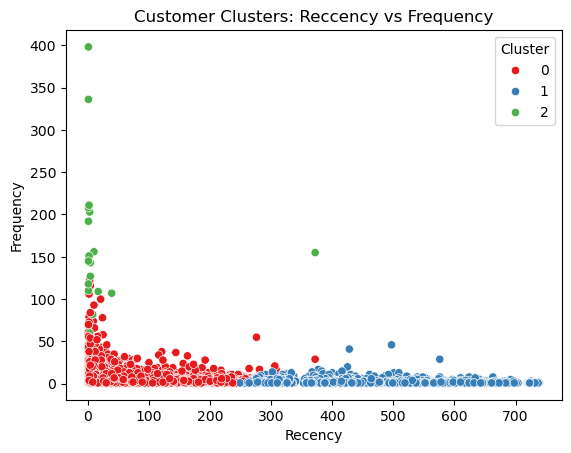

In [192]:
plt.Figure(figsize=(8,6))

sns.scatterplot(data=RFM,
                x='Recency',
                y='Frequency',
                hue='Cluster',
                palette='Set1')

plt.title('Customer Clusters: Reccency vs Frequency')
plt.xlabel('Recency')
plt.ylabel('Frequency')

plt.show()

## Business Insights

### Cluster 0 - Regular Customers
- Recently purchased products.
- Moderate purchase frequency.
- Moderate spending.
- Recommendation: Offer loyalty rewards and personalized product recommendations.

### Cluster 1 - Lost Customers
- Long time since last purchase.
- Low purchase frequency.
- Low spending.
- Recommendation: Launch win-back campaigns with discounts and reminder emails.

### Cluster 2 - VIP Customers
- Very recent purchases.
- Extremely high purchase frequency.
- Highest spending customers.
- Recommendation: Provide premium support, exclusive offers, and early access to products.